# **Sleep Time Prediction**

# **Load dataset**

In [1]:
import kagglehub
import os
path = kagglehub.dataset_download("govindaramsriram/sleep-time-prediction")
print("Path to dataset files:", path)
files = os.listdir(path)
print("Files in the dataset directory:", files)

C:\Users\Sanjam\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 28.1k/28.1k [00:00<00:00, 163kB/s]

Extracting files...
Path to dataset files: C:\Users\Sanjam\.cache\kagglehub\datasets\govindaramsriram\sleep-time-prediction\versions\1
Files in the dataset directory: ['sleeptime_prediction_dataset.csv']


In [2]:
import pandas as pd
df = pd.read_csv(os.path.join(path, 'sleeptime_prediction_dataset.csv'))
df

,WorkoutTime,ReadingTime,PhoneTime,WorkHours,CaffeineIntake,RelaxationTime,SleepTime
0,1.12,0.52,3.29,7.89,216.08,0.75,3.45
1,2.85,0.49,4.22,5.03,206.18,0.67,4.88
2,2.20,1.81,4.04,9.23,28.73,0.35,3.61
3,1.80,0.50,1.62,7.68,276.77,1.21,4.94
4,0.47,0.54,1.60,4.94,170.54,0.95,5.50
...,...,...,...,...,...,...,...
1995,1.97,0.88,3.74,5.64,257.30,0.01,4.24
1996,2.87,0.67,3.01,5.26,269.25,1.75,5.89
1997,0.21,0.79,4.06,6.73,284.01,0.61,3.00
1998,0.17,1.06,2.94,9.45,119.25,1.88,3.53


#Checking dataset

Checking for unique values in each attribute

In [3]:
unique_counts = df.nunique()
print(unique_counts)

WorkoutTime        300
ReadingTime        201
PhoneTime          394
WorkHours          581
CaffeineIntake    1939
RelaxationTime     201
SleepTime          475
dtype: int64


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   WorkoutTime     2000 non-null   float64
 1   ReadingTime     2000 non-null   float64
 2   PhoneTime       2000 non-null   float64
 3   WorkHours       2000 non-null   float64
 4   CaffeineIntake  2000 non-null   float64
 5   RelaxationTime  2000 non-null   float64
 6   SleepTime       2000 non-null   float64
dtypes: float64(7)
memory usage: 109.5 KB


Checking if there are any null values

In [5]:
df.isnull().sum()/len(df)

WorkoutTime       0.0
ReadingTime       0.0
PhoneTime         0.0
WorkHours         0.0
CaffeineIntake    0.0
RelaxationTime    0.0
SleepTime         0.0
dtype: float64

In [6]:
df.describe()

,WorkoutTime,ReadingTime,PhoneTime,WorkHours,CaffeineIntake,RelaxationTime,SleepTime
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1.495915,0.992785,2.985195,6.926945,147.493780,1.010955,4.884375
std,0.876639,0.577303,1.151776,1.723843,84.651139,0.582619,2.028892
min,0.010000,0.000000,1.000000,4.000000,0.020000,0.000000,0.150000
25%,0.710000,0.500000,1.990000,5.440000,75.980000,0.510000,3.840000
50%,1.520000,0.990000,2.965000,6.910000,146.010000,1.010000,4.600000
75%,2.250000,1.500000,3.960000,8.422500,218.902500,1.530000,5.470000
max,3.000000,2.000000,5.000000,10.000000,299.850000,2.000000,19.810000


#Analyzing Data

## Removing outliers

As we can see there are some people who sleep very less (0.15 hrs) and some people who sleep 19 hours, these values will serve as outliers and will lead to poor predictions. So we will remove these outliers

In [7]:
df = df[df["SleepTime"] < 10.0]
df = df[df["SleepTime"] > 3.0]

## Checking Correlation

In [8]:
df.corr()

,WorkoutTime,ReadingTime,PhoneTime,WorkHours,CaffeineIntake,RelaxationTime,SleepTime
WorkoutTime,1.000000,-0.008109,0.117183,0.115065,-0.044316,-0.010849,0.264014
ReadingTime,-0.008109,1.000000,0.032001,-0.000181,0.011810,0.020236,0.118603
PhoneTime,0.117183,0.032001,1.000000,-0.086967,-0.011811,-0.019172,-0.529666
WorkHours,0.115065,-0.000181,-0.086967,1.000000,-0.029051,0.073827,-0.513173
CaffeineIntake,-0.044316,0.011810,-0.011811,-0.029051,1.000000,-0.039670,-0.178738
RelaxationTime,-0.010849,0.020236,-0.019172,0.073827,-0.039670,1.000000,0.196653
SleepTime,0.264014,0.118603,-0.529666,-0.513173,-0.178738,0.196653,1.000000


## Checking relation using scatterplot

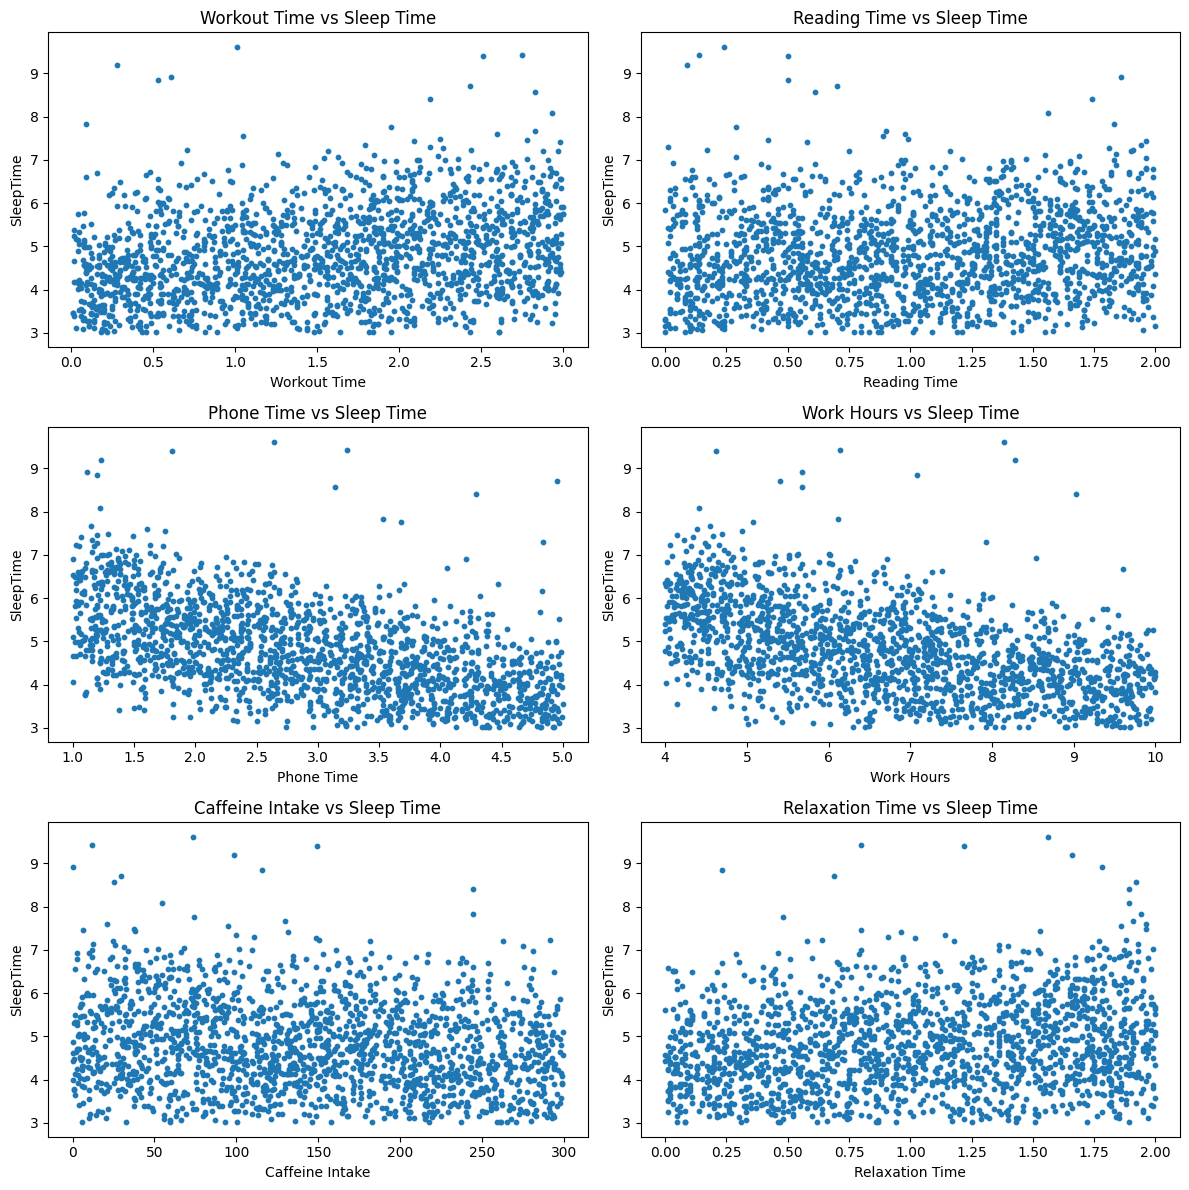

In [9]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

axes[0,0].scatter(df['WorkoutTime'], df['SleepTime'], color='#1f77b4', s=10)
axes[0,0].set_title("Workout Time vs Sleep Time")
axes[0,0].set_xlabel("Workout Time")
axes[0,0].set_ylabel("SleepTime")

axes[0,1].scatter(df['ReadingTime'], df['SleepTime'], color='#1f77b4', s=10)
axes[0,1].set_title("Reading Time vs Sleep Time")
axes[0,1].set_xlabel("Reading Time")
axes[0,1].set_ylabel("SleepTime")

axes[1,0].scatter(df['PhoneTime'], df['SleepTime'], color='#1f77b4', s=10)
axes[1,0].set_title("Phone Time vs Sleep Time")
axes[1,0].set_xlabel("Phone Time")
axes[1,0].set_ylabel("SleepTime")

axes[1,1].scatter(df['WorkHours'], df['SleepTime'], color='#1f77b4', s=10)
axes[1,1].set_title("Work Hours vs Sleep Time")
axes[1,1].set_xlabel("Work Hours")
axes[1,1].set_ylabel("SleepTime")

axes[2,0].scatter(df['CaffeineIntake'], df['SleepTime'], color='#1f77b4', s=10)
axes[2,0].set_title("Caffeine Intake vs Sleep Time")
axes[2,0].set_xlabel("Caffeine Intake")
axes[2,0].set_ylabel("SleepTime")

axes[2,1].scatter(df['RelaxationTime'], df['SleepTime'], color='#1f77b4', s=10)
axes[2,1].set_title("Relaxation Time vs Sleep Time")
axes[2,1].set_xlabel("Relaxation Time")
axes[2,1].set_ylabel("SleepTime")

plt.tight_layout()
plt.show()

# **Data Preparation**

## Data Separation

In [10]:
y = df['SleepTime']
y

0       3.45
1       4.88
2       3.61
3       4.94
4       5.50
        ... 
1994    7.48
1995    4.24
1996    5.89
1998    3.53
1999    5.83
Name: SleepTime, Length: 1788, dtype: float64

In [11]:
X = df.drop('SleepTime', axis = 1)
X

,WorkoutTime,ReadingTime,PhoneTime,WorkHours,CaffeineIntake,RelaxationTime
0,1.12,0.52,3.29,7.89,216.08,0.75
1,2.85,0.49,4.22,5.03,206.18,0.67
2,2.20,1.81,4.04,9.23,28.73,0.35
3,1.80,0.50,1.62,7.68,276.77,1.21
4,0.47,0.54,1.60,4.94,170.54,0.95
...,...,...,...,...,...,...
1994,2.25,0.99,1.29,4.70,37.38,1.96
1995,1.97,0.88,3.74,5.64,257.30,0.01
1996,2.87,0.67,3.01,5.26,269.25,1.75
1998,0.17,1.06,2.94,9.45,119.25,1.88


## Train-Test Split and Standardization

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

## Verify Prepared Data

In [13]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1430, 6)
X_test shape: (358, 6)
y_train shape: (1430,)
y_test shape: (358,)


In [14]:
X_train

array([[-1.46074514, -1.67344663, -1.13675304,  1.76408864,  0.07591155,
         1.65809363],
       [ 1.31338882,  1.38398218,  1.42340144,  0.66433362, -0.33872165,
        -0.7026372 ],
       [-0.09660489, -0.75274364, -1.03964373,  0.91536466,  1.61192572,
        -0.87247395],
       ...,
       [-1.48367187, -1.08280698,  0.26691787,  0.26387935, -0.79913752,
        -0.65168618],
       [-0.57806616, -1.23915277,  0.39933965,  0.52088731,  0.72181192,
         1.36937115],
       [-0.11953162, -1.36075505,  1.75886996,  1.63857313,  0.503491  ,
         0.7239915 ]], shape=(1430, 6))

In [15]:
X_test

array([[ 1.31338882, -1.39549856,  1.55582322,  0.11445611,  0.97967776,
         1.23350175],
       [ 0.38485638, -0.35319328,  0.69949569, -1.1048375 , -0.82656004,
         0.69002415],
       [ 1.47387591,  1.14077762,  0.41699589, -0.74622173, -0.58976128,
        -0.26106165],
       ...,
       [-0.57806616,  0.04635707, -0.55409719,  1.42340366,  1.46987001,
        -0.85549028],
       [ 1.27899873,  1.55769973, -1.31331541,  1.1066264 ,  1.7475083 ,
         1.1315997 ],
       [-0.00489798,  1.15814937, -1.24269046, -1.18851452,  0.74582134,
        -0.60073515]], shape=(358, 6))

# **Model Selection**

Importing libraries

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

Tuning the hyperparameters for each model



In [17]:
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(max_depth = None, min_samples_split = 2, random_state = 42),

    "Gradient Boost": GradientBoostingRegressor(n_estimators = 500, max_depth = 4,
      min_samples_split = 5, learning_rate = 0.01, loss = 'squared_error'),

    "Support Vector": SVR(kernel = 'rbf', C = 100, gamma = 0.1, epsilon = .1),

    "Ada Boost": AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3),
    n_estimators=200, learning_rate=0.05, random_state = 42),

    "XG Boost": xgb.XGBRegressor(n_estimators = 500, max_depth = 4, learning_rate = 0.01)
}

Running each regression model on the dataset

In [18]:
results = []
model_predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    model_predictions[name] = y_test_pred

    train_mse = mean_squared_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results.append([name, train_mse, train_r2, test_mse, test_r2])

## Checking the results

In [19]:
df_results = pd.DataFrame(results, columns=["Method", "Training MSE", "Training R2", "Test MSE", "Test R2"])

print(df_results)

              Method  Training MSE  Training R2  Test MSE   Test R2
0  Linear Regression      0.147186     0.864090  0.138148  0.862355
1      Random Forest      0.030678     0.971673  0.199585  0.801143
2     Gradient Boost      0.070450     0.934947  0.198711  0.802013
3     Support Vector      0.124063     0.885442  0.142883  0.857638
4          Ada Boost      0.356116     0.671166  0.425620  0.575932
5           XG Boost      0.082560     0.923765  0.193480  0.807225


As we can see Linear Regression has the best Test R2 score and minimum Test MSE, it is the best regression model for this dataset

# **Data Visualization of prediction results**

Importing the libraries

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Comparing MSE of each model

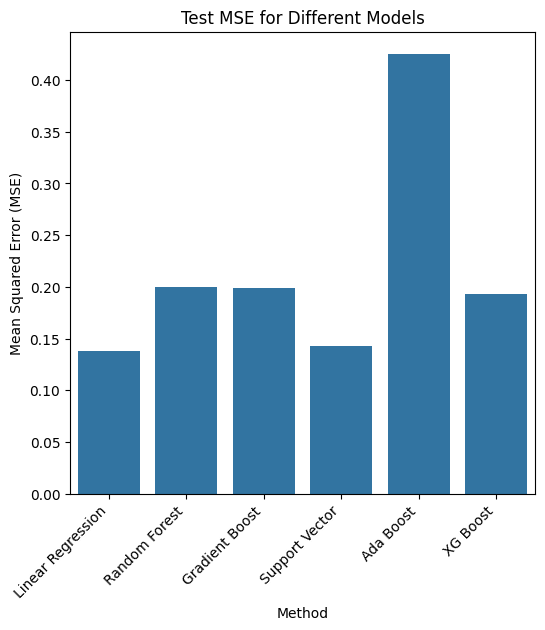

In [21]:
plt.figure(figsize=(6, 6))
sns.barplot(x="Method", y="Test MSE", data=df_results)

plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Test MSE for Different Models")

plt.show()

Comparing R2 score of each model

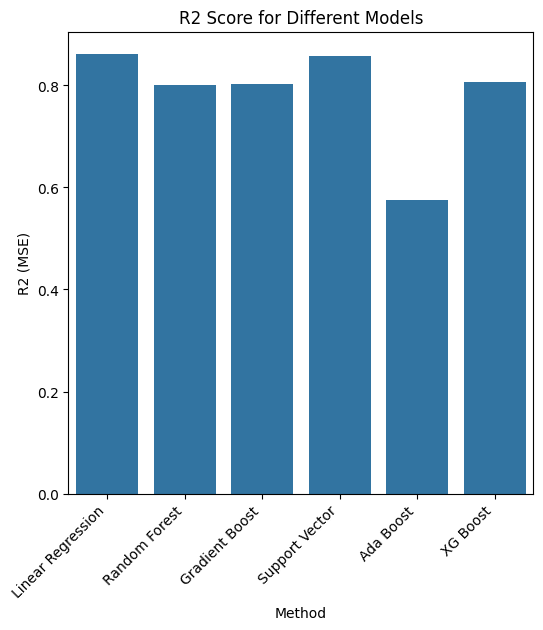

In [22]:
plt.figure(figsize=(6, 6))
sns.barplot(x="Method", y="Test R2", data=df_results)

plt.xticks(rotation=45, ha='right')
plt.ylabel("R2 (MSE)")
plt.title("R2 Score for Different Models")

plt.show()

Graph of actual v/s predicted values

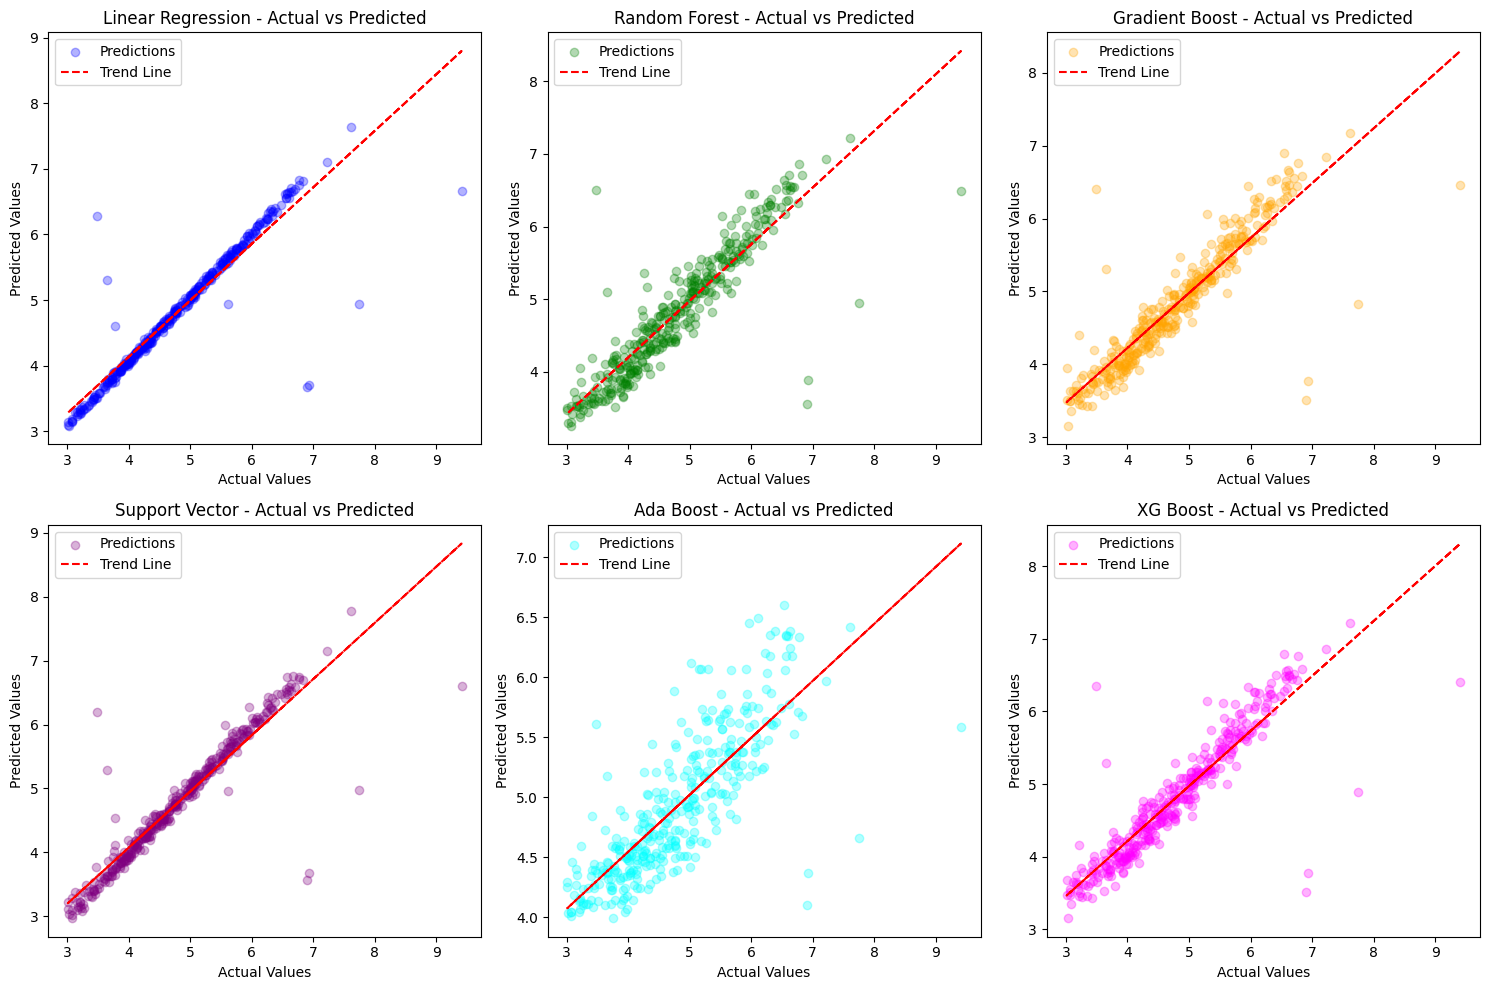

In [23]:
colors = ['blue', 'green', 'orange', 'purple', 'cyan', 'magenta']

plt.figure(figsize=(15, 10))

for i, (name, y_pred) in enumerate(model_predictions.items()):
    plt.subplot(2, 3, i + 1)
    plt.scatter(y_test, y_pred, alpha=0.3, color=colors[i % len(colors)], label="Predictions")

    z = np.polyfit(y_test, y_pred, 1)
    p = np.poly1d(z)
    plt.plot(y_test, p(y_test), color='red', linestyle='--', label="Trend Line")

    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{name} - Actual vs Predicted")
    plt.legend()

plt.tight_layout()
plt.show()

#Saving the Best Model

In [24]:
from sklearn.linear_model import LinearRegression
import pickle

best_model = LinearRegression()
best_model.fit(X_train, y_train)

with open("model.pkl", "wb") as model_file:
    pickle.dump(best_model, model_file)

with open("scaler.pkl", "wb") as scaler_file:
    pickle.dump(scaler, scaler_file)

print("Saved model.pkl and scaler.pkl")

Saved model.pkl and scaler.pkl
